In [1]:
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
music_df = pd.read_csv('./data/train.csv', usecols=['weekly_hours', 'customer_service_inquiries', 'churned'], nrows=1000)
music_df

,customer_service_inquiries,weekly_hours,churned
0,Medium,22.391362,0
1,Low,29.294210,1
2,High,15.400312,0
3,Medium,22.842084,0
4,High,23.151163,0
...,...,...,...
995,Medium,14.244616,0
996,Medium,29.146602,1
997,High,1.494748,1
998,High,5.522787,1


In [4]:
# 숫자형 인코딩
music_df.info()

mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
}

music_df['customer_service_inquiries'] = music_df['customer_service_inquiries'].map(mapping)

music_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_service_inquiries  1000 non-null   str    
 1   weekly_hours                1000 non-null   float64
 2   churned                     1000 non-null   int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 23.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_service_inquiries  1000 non-null   int64  
 1   weekly_hours                1000 non-null   float64
 2   churned                     1000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


In [16]:
from sklearn.model_selection import train_test_split

X = music_df[['weekly_hours', 'customer_service_inquiries']]
y = music_df['churned']

# 학습/평가셋 구분
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 학습/검증셋 구분
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(X_tr.shape, y_tr.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(720, 2) (720,)
(80, 2) (80,)
(200, 2) (200,)


In [17]:
from catboost import Pool, CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
# 4. CatBoost 모델 학습
# 범주형 컬럼을 CatBoost에 알려줍니다. (자동으로 Target Encoding 수행)

def catboost(X_tr, X_val, y_tr, y_val):
    cat_features = ['customer_service_inquiries']

    # CatBoost 모델 초기화 및 학습 (verbose=False로 학습 로그 숨김)
    cat_clf = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        cat_features=cat_features,    # 범주형 컬럼 리스트
        random_seed=42,
        early_stopping_rounds=50,
        eval_metric='AUC',
        verbose=100                  # 100번째마다 점수 출력
)

    # 2. 모델 학습 (eval_set에 val 데이터를 넣어줍니다)
    cat_clf.fit(
        X_tr, y_tr,
       eval_set=(X_val, y_val),
        use_best_model=True
)
    return cat_clf



def report_cat(cat_clf, X_tr, X_test, y_tr, y_test):
    # 예측
    y_pred_tr = cat_clf.predict(X_tr)
    # print(y_pred_tr)
    y_pred_train = (y_pred_tr > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    # print(y_pred_train)

    y_pred_ = cat_clf.predict(X_test)
    # print(y_pred_)
    y_pred_test = (y_pred_ > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    print(f'테스트 예측: {y_pred_test[:10]}')
    print(f'테스트 결과: {y_test.values[:10]}')

    # 평가 지표
    # -- acc, precision, recall, f1_score
    train_result = classification_report(y_tr, y_pred_train)
    test_result = classification_report(y_test, y_pred_test)

    # -- roc_curve
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_pred_train)
    fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_test)

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_te = auc(fpr_te, tpr_te)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve (Train vs Test)")
    plt.legend()
    plt.grid(True)

    return train_result, test_result, plt.show()


# def main(X_tr, X_val, y_tr, y_val, X_test, y_test):
#     cat_clf = catboost(X_tr, X_val, y_tr, y_val)
#     result1, result2, show = report_cat(cat_clf, X_tr, X_test, y_tr, y_test)
#     #
#     # # 특성 중요도 (추가)
#     # plot_importance(xgb_clf)
#     # plt.show()
#
#     return f'catboost 학습셋 평가지표: {result1}\ncatboost 평가셋 평가지표: {result2}'
#
# print(main(X_tr, X_val, y_tr, y_val, X_test, y_test))

In [18]:
# 모델 학습
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
from xgboost import plot_importance


def xgboost(X_tr, X_val, y_tr, y_val):
    xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    early_stopping_rounds=10,  # 10번 정도 연속적으로 개선이 안되면 학습 조기 종료
    eval_metric='logloss'     # 평가지표: 이진분류 손실 logloss로 진행
)
    xgb_clf.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=100
)
    return xgb_clf



def report_xgb(xgb_clf, X_tr, X_test, y_tr, y_test):
    # 예측
    y_pred_tr = xgb_clf.predict(X_tr)
    # print(y_pred_tr)
    y_pred_train = (y_pred_tr > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    # print(y_pred_train)

    y_pred_ = xgb_clf.predict(X_test)
    # print(y_pred_)
    y_pred_test = (y_pred_ > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    print(f'테스트 예측: {y_pred_test[:10]}')
    print(f'테스트 결과: {y_test.values[:10]}')

    # 평가 지표
    # -- acc, precision, recall, f1_score
    train_result = classification_report(y_tr, y_pred_train)
    test_result = classification_report(y_test, y_pred_test)

    # -- roc_curve
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_pred_train)
    fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_test)

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_te = auc(fpr_te, tpr_te)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve (Train vs Test)")
    plt.legend()
    plt.grid(True)

    return train_result, test_result, plt.show()

#
# def main(X_tr, X_val, y_tr, y_val, X_test, y_test):
#     xgb_clf = xgboost(X_tr, X_val, y_tr, y_val)
#     result1, result2, show = report_xgb(xgb_clf, X_tr, X_test, y_tr, y_test)
#     #
#     # # 특성 중요도 (추가)
#     # plot_importance(xgb_clf)
#     # plt.show()
#
#     return f'xgboost 학습셋 평가지표: {result1}\nxgboost 평가셋 평가지표: {result2}'
#
# print(main(X_tr, X_val, y_tr, y_val, X_test, y_test))

In [19]:
# 모델 학습, 평가 임포트
from lightgbm import LGBMClassifier, early_stopping, LGBMRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
# 특성 중요도 임포트
from lightgbm import plot_importance
import matplotlib.pyplot as plt



def light_GBM(X_tr, X_val, y_tr, y_val):
    """ 학습 """
    lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    random_state=42,
    # verbose=1,    # 경고/정보 로그
    verbose=-1,     # 간단하게
)
    lgbm_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr,y_tr),(X_val, y_val)],
    eval_metric="logloss",         # 이진분류 손실(낮을수록 좋음)
    callbacks=[early_stopping(stopping_rounds=10, verbose=True)],     # 검증 점수 개선이 이후 10회 없으면 조기종료
)
    return lgbm_clf





def report_lgbm(lgbm_clf, X_tr, X_test, y_tr, y_test):
    # 예측
    y_pred_tr = lgbm_clf.predict(X_tr)
    # print(y_pred_tr)
    y_pred_train = (y_pred_tr > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    # print(y_pred_train)

    y_pred_ = lgbm_clf.predict(X_test)
    # print(y_pred_)
    y_pred_test = (y_pred_ > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    print(f'테스트 예측: {y_pred_test[:10]}')
    print(f'테스트 결과: {y_test.values[:10]}')

    # 평가 지표
    # -- acc, precision, recall, f1_score
    train_result = classification_report(y_tr, y_pred_train)
    test_result = classification_report(y_test, y_pred_test)

    # -- roc_curve
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_pred_train)
    fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_test)

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_te = auc(fpr_te, tpr_te)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve (Train vs Test)")
    plt.legend()
    plt.grid(True)

    return train_result, test_result, plt.show()




#
# def main(X_tr, X_val, y_tr, y_val, X_test, y_test):
#     lgbm_clf = light_GBM(X_tr, X_val, y_tr, y_val)
#     result1, result2, show = report_lgbm(lgbm_clf, X_tr, X_test, y_tr, y_test)
#
#     # # 특성 중요도 (추가)
#     # plot_importance(lgbm_clf)
#     # plt.show()
#
#     return f'lgbm 학습셋 평가지표: {result1}\nlgbm 평가셋 평가지표: {result2}'
#
#
#
#
# print(main(X_tr, X_val, y_tr, y_val, X_test, y_test))

In [20]:
# ================================
# 4) 모델 정의 및 학습(RandomForest)
# ================================
from sklearn.ensemble import RandomForestClassifier

def random_forest(X_tr, X_val, y_tr, y_val):
    rand_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
)

    # 학습 수행 (Train split 기준)
    rand_model.fit(X_tr, y_tr)

    return rand_model



def report_rand(rand_model, X_tr, X_test, y_tr, y_test):
    # 예측
    y_pred_tr = rand_model.predict(X_tr)
    # print(y_pred_tr)
    y_pred_train = (y_pred_tr > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    # print(y_pred_train)

    y_pred_ = rand_model.predict(X_test)
    # print(y_pred_)
    y_pred_test = (y_pred_ > 0.5).astype(int)   # 임계값 0.5로 클래스 분류하기
    print(f'테스트 예측: {y_pred_test[:10]}')
    print(f'테스트 결과: {y_test.values[:10]}')

    # 평가 지표
    # -- acc, precision, recall, f1_score
    train_result = classification_report(y_tr, y_pred_train)
    test_result = classification_report(y_test, y_pred_test)

    # -- roc_curve
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, y_pred_train)
    fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_test)

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_te = auc(fpr_te, tpr_te)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
    plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve (Train vs Test)")
    plt.legend()
    plt.grid(True)

    return train_result, test_result, plt.show()





# def main(X_tr, X_val, y_tr, y_val, X_test, y_test):
#     rand_model = random_forest(X_tr, X_val, y_tr, y_val)
#     result1, result2, show = report_rand(rand_model, X_tr, X_test, y_tr, y_test)
#
#     # # 특성 중요도 (추가)
#     # plot_importance(lgbm_clf)
#     # plt.show()
#
#     return f'random-forest 학습셋 평가지표: {result1}\nrandom-forest 평가셋 평가지표: {result2}'
#
#
#
#
# print(main(X_tr, X_val, y_tr, y_val, X_test, y_test))

0:	test: 0.7548468	best: 0.7548468 (0)	total: 24.8ms	remaining: 24.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7898686679
bestIteration = 24

Shrink model to first 25 iterations.
테스트 예측: [0 1 1 1 0 1 0 0 0 0]
테스트 결과: [1 0 1 0 1 1 1 0 0 0]


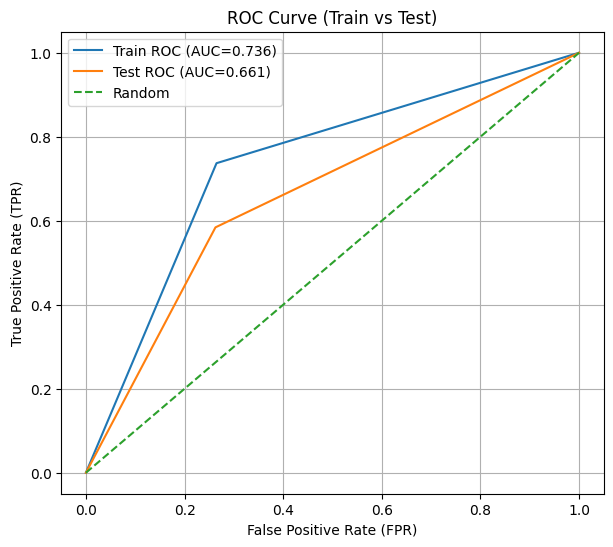

[0]	validation_0-logloss:0.66121	validation_1-logloss:0.66949
[27]	validation_0-logloss:0.45713	validation_1-logloss:0.56319
테스트 예측: [0 1 1 1 0 1 0 0 0 1]
테스트 결과: [1 0 1 0 1 1 1 0 0 0]


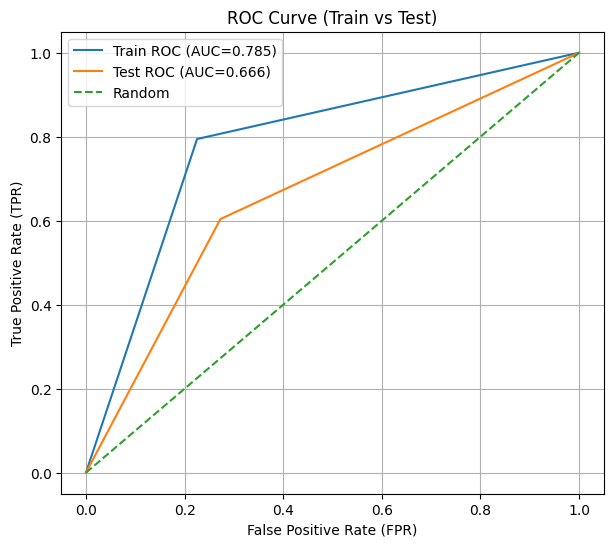

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[132]	training's binary_logloss: 0.499107	valid_1's binary_logloss: 0.581044
테스트 예측: [0 1 1 1 0 1 0 0 0 1]
테스트 결과: [1 0 1 0 1 1 1 0 0 0]


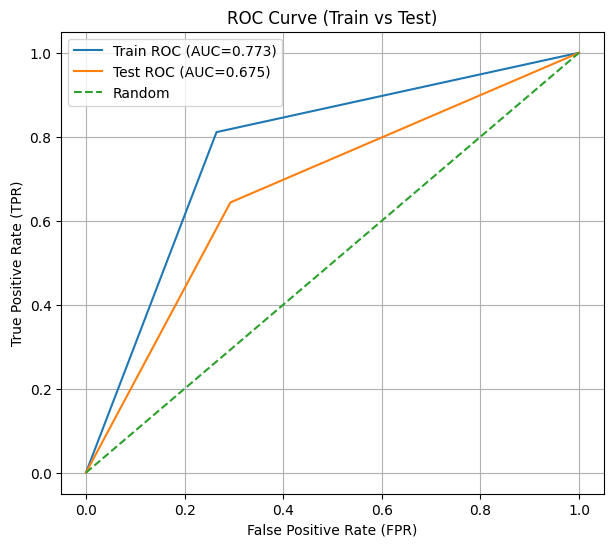

테스트 예측: [0 1 1 1 0 1 0 0 0 1]
테스트 결과: [1 0 1 0 1 1 1 0 0 0]


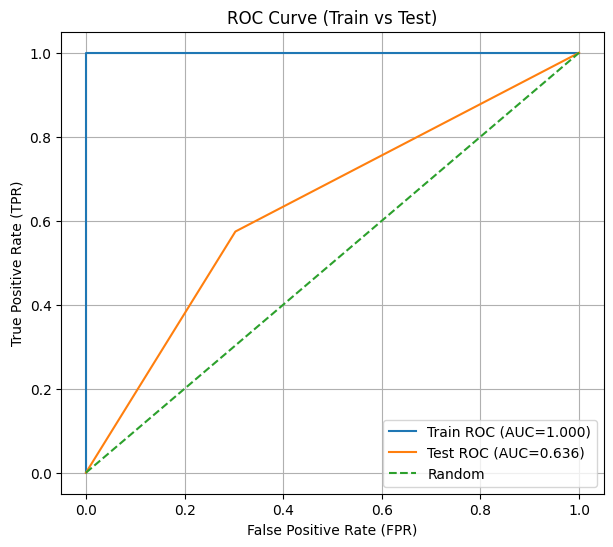

catboost 학습셋 평가지표:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73       355
           1       0.74      0.74      0.74       365

    accuracy                           0.74       720
   macro avg       0.74      0.74      0.74       720
weighted avg       0.74      0.74      0.74       720

catboost 평가셋 평가지표:
              precision    recall  f1-score   support

           0       0.63      0.74      0.68        99
           1       0.69      0.58      0.63       101

    accuracy                           0.66       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.66      0.66       200

xgboost 학습셋 평가지표:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       355
           1       0.78      0.79      0.79       365

    accuracy                           0.78       720
   macro avg       0.78      0.78      0.78       720
weighted avg      

In [25]:
def main(X_tr, X_val, y_tr, y_val, X_test, y_test):
    # CatBoost
    cat_clf = catboost(X_tr, X_val, y_tr, y_val)
    result_cat1, result_cat2, show_cat = report_cat(cat_clf, X_tr, X_test, y_tr, y_test)

    # XGBoost
    xgb_clf = xgboost(X_tr, X_val, y_tr, y_val)
    result_xgb1, result_xgb2, show_xgb = report_xgb(xgb_clf, X_tr, X_test, y_tr, y_test)

    # LightGBM
    lgbm_clf = light_GBM(X_tr, X_val, y_tr, y_val)
    result_lgbm1, result_lgbm2, show_lgbm = report_lgbm(lgbm_clf, X_tr, X_test, y_tr, y_test)

    # RandomForest
    rand_model = random_forest(X_tr, X_val, y_tr, y_val)
    result_rand1, result_rand2, show_rand = report_rand(rand_model, X_tr, X_test, y_tr, y_test)

    return f'catboost 학습셋 평가지표:\n{result_cat1}\ncatboost 평가셋 평가지표:\n{result_cat2}\nxgboost 학습셋 평가지표:\n{result_xgb1}\nxgboost 평가셋 평가지표:\n{result_xgb2}\nlgbm 학습셋 평가지표:\n{result_lgbm1}\nlgbm 평가셋 평가지표:\n{result_lgbm2}\nrandom-forest 학습셋 평가지표:\n{result_rand1}\nrandom-forest 평가셋 평가지표:\n{result_rand2}'

print(main(X_tr, X_val, y_tr, y_val, X_test, y_test))